<a href="https://colab.research.google.com/github/dark452/master-data-science-ai/blob/main/trimester-1/mcdi502/project/Taller1_grupo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acceder a los archivos de Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Instalar entorno de Spark

## Instalar JDK, PySpark y Hadoop



In [2]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.9/spark-3.5.9-bin-hadoop3.tgz
!tar xf spark-3.5.9-bin-hadoop3.tgz
# Instalar las bibliotecas de Python necesarias
!pip install -q pyspark==3.5.9 &> /dev/null
!pip install -q findspark &> /dev/null

## Creación de variables de entorno



In [3]:
import os # libreria de manejo del sistema operativo
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.9-bin-hadoop3"
os.environ["PYTHON_PATH"] = "/content/spark-3.5.9-bin-hadoop3/python/lib/py4j-0.10.9-src.zip"

## Creación Sesión y SparkContext

In [4]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder\
        .master("local[*]")\
        .appName('Taller 1 - Grupo 1')\
        .getOrCreate()
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext
sc

<SparkContext master=local[*] appName=Taller 1 - Grupo 1>

# RDDs: Creación y unión

## Creen un RDD llamado deportista con 6 particiones, leyendo el archivo deportista.csv.

In [5]:
carpeta = "/content/drive/MyDrive/Magister - Ciencia de Datos e Inteligencia Artificial/Gestión de Datos y Tecnologías Big Data/Archivos Sumativa 2/"
deportistas_ = sc.textFile(carpeta+"deportista.csv", 6)
deportistas_.take(5)
#imprimimos las particiones
print(f"Particiones de deportistas.csv: {deportistas_.getNumPartitions()}")

Particiones de deportistas.csv: 6


In [6]:
import os

# Get the base directory path from the 'carpeta' variable
directory_path = carpeta

# List all files and directories in the specified path
files_in_directory = os.listdir(directory_path)

# Check if 'deportista.csv' is in the list of files
file_name = "deportista.csv"
if file_name in files_in_directory:
    print(f"[OK] El archivo '{file_name}' se encuentra en la ruta: {directory_path}")
else:
    print(f"[ERROR] El archivo '{file_name}' NO se encuentra en la ruta: {directory_path}")
    print("Archivos encontrados en el directorio:")
    for f in files_in_directory:
        print(f"- {f}")

[OK] El archivo 'deportista.csv' se encuentra en la ruta: /content/drive/MyDrive/Magister - Ciencia de Datos e Inteligencia Artificial/Gestión de Datos y Tecnologías Big Data/Archivos Sumativa 2/


## Creen un RDD llamado deportista2, leyendo el archivo deportista2.csv

In [7]:
deportistas2_ = sc.textFile(carpeta+"deportista2.csv")
deportistas2_.take(5)
#imprimimos las particiones
print(f"Particiones de deportistas2.csv: {deportistas2_.getNumPartitions()}")

Particiones de deportistas2.csv: 2


## Creen un nuevo RDD llamado deportistaTotal que contenga la unión de los RDDs deportista y deportista2.

In [8]:
deportistaTotal = deportistas_.union(deportistas2_)
deportistaTotal.take(5)
print(deportistaTotal.getNumPartitions())

8


## Muestren la cantidad de registros contenidos en deportistaTotal.

In [9]:

print(f"deportistaTotal tiene {deportistaTotal.count()} registros en total")

deportistaTotal tiene 135571 registros en total


## Conviertan el RDD deportistaTotal en un DataFrame llamado deportista con las siguientes columnas: "deportista_id", "nombre", "genero", "edad", "altura", "peso", "equipo_id".

In [10]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType
schema_deportista = StructType([
    StructField("deportista_id", IntegerType(), True),
    StructField("nombre",        StringType(),  True),
    StructField("genero",        IntegerType(), True),
    StructField("edad",          IntegerType(), True),
    StructField("altura",        IntegerType(), True),
    StructField("peso",          FloatType(),   True),
    StructField("equipo_id",     IntegerType(), True)
])
rdd_parseado= deportistaTotal.map(lambda row: row.split(","))
deportista = (spark.read.option("quote", "'").schema(schema_deportista).csv(deportistaTotal))
deportista.show(5)
deportista.printSchema()

+-------------+--------------------+------+----+------+----+---------+
|deportista_id|              nombre|genero|edad|altura|peso|equipo_id|
+-------------+--------------------+------+----+------+----+---------+
|            1|           A Dijiang|     1|  24|   180|80.0|      199|
|            2|            A Lamusi|     1|  23|   170|60.0|      199|
|            3| Gunnar Nielsen Aaby|     1|  24|     0| 0.0|      273|
|            4|Edgar Lindenau Aabye|     1|  34|     0| 0.0|      278|
|            5|Christine Jacoba ...|     2|  21|   185|82.0|      705|
+-------------+--------------------+------+----+------+----+---------+
only showing top 5 rows

root
 |-- deportista_id: integer (nullable = true)
 |-- nombre: string (nullable = true)
 |-- genero: integer (nullable = true)
 |-- edad: integer (nullable = true)
 |-- altura: integer (nullable = true)
 |-- peso: float (nullable = true)
 |-- equipo_id: integer (nullable = true)



#  RDDs: transformaciones
Creen un RDD llamado MayorEdad que permita filtrar deportistas mayores de edad.

In [11]:
# Usamos rdd_parseado, la edad es la columna 3
MayorEdad = rdd_parseado.filter(lambda columnas: int(columnas[3]) >= 18)
print(f"Mayores de edad: {MayorEdad.count()} personas")
MayorEdad.take(10)


Mayores de edad: 123244 personas


[['1', 'A Dijiang', '1', '24', '180', '80', '199'],
 ['2', 'A Lamusi', '1', '23', '170', '60', '199'],
 ['3', 'Gunnar Nielsen Aaby', '1', '24', '0', '0', '273'],
 ['4', 'Edgar Lindenau Aabye', '1', '34', '0', '0', '278'],
 ['5', 'Christine Jacoba Aaftink', '2', '21', '185', '82', '705'],
 ['6', 'Per Knut Aaland', '1', '31', '188', '75', '1096'],
 ['7', 'John Aalberg', '1', '31', '183', '72', '1096'],
 ['8', 'Cornelia Cor Aalten Strannood ', '2', '18', '168', '0', '705'],
 ['9', 'Antti Sami Aalto', '1', '26', '186', '96', '350'],
 ['10', 'Einar Ferdinand Einari Aalto', '1', '26', '0', '0', '350']]

## Creen un RDD llamado Deportistas_mujer que muestre solo los deportistas del género femenino (sexo=2)


In [12]:
# Usamos rdd_parseado, el genero es la columna 2
Deportistas_mujer = rdd_parseado.filter(lambda columnas: int(columnas[2]) == 2)
print(f"Deportistas Mujeres: {Deportistas_mujer.count()} totales")
Deportistas_mujer.take(10)



Deportistas Mujeres: 33981 totales


[['5', 'Christine Jacoba Aaftink', '2', '21', '185', '82', '705'],
 ['8', 'Cornelia Cor Aalten Strannood ', '2', '18', '168', '0', '705'],
 ['13', 'Minna Maarit Aalto', '2', '30', '159', '55.5', '350'],
 ['14', 'Pirjo Hannele Aalto Mattila ', '2', '32', '171', '65', '350'],
 ['21', 'Ragnhild Margrethe Aamodt', '2', '27', '163', '0', '742'],
 ['22', 'Andreea Aanei', '2', '22', '170', '125', '861'],
 ['26', 'Agnes Erika Aanonsen Eyde ', '2', '17', '169', '65', '742'],
 ['29', 'Willemien Aardenburg', '2', '22', '0', '0', '705'],
 ['37', 'Ann Kristin Aarnes', '2', '23', '182', '64', '742'],
 ['49', 'Moonika Aava', '2', '24', '168', '65', '331']]

## Conviertan a mayúsculas todas las palabras del RDD deportistaTotal.

In [13]:
Mayus = deportistaTotal.map(lambda x: x.upper())
Mayus.take(10)

['1,A DIJIANG,1,24,180,80,199',
 '2,A LAMUSI,1,23,170,60,199',
 '3,GUNNAR NIELSEN AABY,1,24,0,0,273',
 '4,EDGAR LINDENAU AABYE,1,34,0,0,278',
 '5,CHRISTINE JACOBA AAFTINK,2,21,185,82,705',
 '6,PER KNUT AALAND,1,31,188,75,1096',
 '7,JOHN AALBERG,1,31,183,72,1096',
 '8,CORNELIA COR AALTEN STRANNOOD ,2,18,168,0,705',
 '9,ANTTI SAMI AALTO,1,26,186,96,350',
 '10,EINAR FERDINAND EINARI AALTO,1,26,0,0,350']

# DataFrames: creación e integración

## Creen los DataFrames Evento, Resultado, Equipos y Juego a partir de los archivos eventos.csv, equipos.csv, resultado.csv y juego.json.


## Carga de Archivos CSV y JSON (DataFrames)
La base de datos para el desarrollo del taller I, cuenta con los siguientes archivos:

* Juegos
* Resultados
* Evento
* Equipo
* Deportista

El modelo de datos se puede observar en el siguiente diagrama::

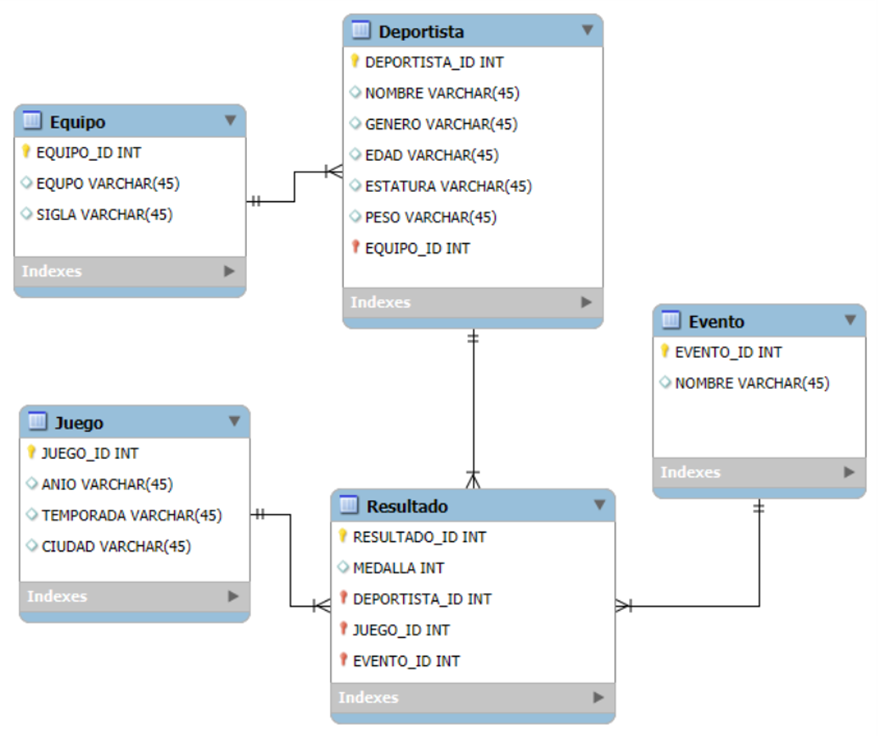

In [14]:
## Cargar archivos
def load_csv_data(archivo, sep):
  try:
    df = spark.read.csv(archivo,sep=sep, inferSchema=True, header=True)
    print(f"[OK] Datos cargados exitosamente desde {archivo}")
    return df
  except FileNotFoundError:
    raise FileNotFoundError(
    f"[ERROR] No se encontró el archivo en {archivo}"
    "Verificar que el archivo CSV se encuentre en google drive."
  )

def load_json_data(archivo):
  try:
    df = spark.read.option("multiline","true").json(archivo)
    print(f"[OK] Datos cargados exitosamente desde {archivo}")
    return df
  except FileNotFoundError:
    raise FileNotFoundError(
    f"[ERROR] No se encontró el archivo en {archivo}"
    "Verificar que el archivo JSON se encuentre en google drive."
  )

df_resultados = load_csv_data(carpeta+"resultados.csv", ';')
#df_deportistas = load_csv_data(carpeta+"deportista.csv", ',')
#df_deportistas2 = load_csv_data(carpeta+"deportista2.csv", ',')
df_equipo = load_csv_data(carpeta+"equipo.csv", ',')
df_evento = load_csv_data(carpeta+"evento.csv", ',')
df_juegos = load_json_data(carpeta+"juegos.json")

#test
df_resultados.show()
#df_deportistas.show()
#df_deportistas2.show()
df_equipo.show()
df_evento.show()
df_juegos.show()

[OK] Datos cargados exitosamente desde /content/drive/MyDrive/Magister - Ciencia de Datos e Inteligencia Artificial/Gestión de Datos y Tecnologías Big Data/Archivos Sumativa 2/resultados.csv
[OK] Datos cargados exitosamente desde /content/drive/MyDrive/Magister - Ciencia de Datos e Inteligencia Artificial/Gestión de Datos y Tecnologías Big Data/Archivos Sumativa 2/equipo.csv
[OK] Datos cargados exitosamente desde /content/drive/MyDrive/Magister - Ciencia de Datos e Inteligencia Artificial/Gestión de Datos y Tecnologías Big Data/Archivos Sumativa 2/evento.csv
[OK] Datos cargados exitosamente desde /content/drive/MyDrive/Magister - Ciencia de Datos e Inteligencia Artificial/Gestión de Datos y Tecnologías Big Data/Archivos Sumativa 2/juegos.json
+------------+-------+-------------+--------+---------+
|resultado_id|medalla|deportista_id|juego_id|evento_id|
+------------+-------+-------------+--------+---------+
|           1|     NA|            1|      39|        1|
|           2|     NA| 

## Realicen la optimización de los DataFrames creados.

In [15]:
# Importar StorageLevel para trabajar con niveles de almacenamiento
from pyspark.storagelevel import StorageLevel

# Verificar si los dataframe creados están en caché
# is_cached: propiedad booleana (True/False)
# Resultado esperado: False (aún no lo hemos cacheado)
print(f"El dataframe resultado: {df_resultados.is_cached}")
print(f"El dataframe equipo: {df_equipo.is_cached}")
print(f"El dataframe evento: {df_evento.is_cached}")
print(f"El dataframe juegos: {df_juegos.is_cached}")

El dataframe resultado: False
El dataframe equipo: False
El dataframe evento: False
El dataframe juegos: False


In [16]:
# Cachear los DataFrame en memoria
# cache() es equivalente a persist(StorageLevel.MEMORY_ONLY)
# El DataFrame se almacenará en memoria la primera vez que se ejecute una acción
df_resultados.cache()
df_equipo.cache()
df_evento.cache()
df_juegos.cache()
# Verificar que ahora está marcado como cacheado
# Resultado esperado: True
print(f"El dataframe resultado: {df_resultados.is_cached} y count {df_resultados.count()}")
print(f"El dataframe equipo: {df_equipo.is_cached} y count {df_equipo.count()}")
print(f"El dataframe evento: {df_evento.is_cached} y count {df_evento.count()}")
print(f"El dataframe juegos: {df_juegos.is_cached} y count {df_juegos.count()}")

El dataframe resultado: True y count 271116
El dataframe equipo: True y count 1184
El dataframe evento: True y count 765
El dataframe juegos: True y count 51


In [17]:
# persist() sin argumentos usa el nivel por defecto (MEMORY_AND_DISK)
# Esto almacena los DataFrame en memoria, y si no cabe, usa disco
df_resultados.persist()
df_equipo.persist()
df_evento.persist()
df_juegos.persist()

DataFrame[ano: string, ciudad: string, juego_id: bigint, temporada: bigint]

## Crearen un nuevo DataFrame que contenga los datos de todos los DataFrames (deportista, evento, equipo, resultado y juego).

In [18]:
# Importar la función broadcast
from pyspark.sql.functions import broadcast
# Realizar un join optimizado con broadcast
# Resultado["deportista_id"] == Deportista["deportista_id"]: condición del join
#df_deportistas = load_csv_data(carpeta+"deportista.csv", ',')
#df_deportistas.show() #hay que agregar las columnas
#df_deportistas = df_deportistas.toDF(*columnas_deportista_df)
#df_deportistas.printSchema()
#df_deportistas.show() #hay que agregar las columnas
print(f"Cantidad de deportistaS: {deportista.count()}")
# Haremos la prueba de diferencia de dataframe totales para inner join y left jon
dfTotal = (df_resultados
          .join(deportista, df_resultados["deportista_id"] == deportista["deportista_id"])
          .join(broadcast(df_evento), df_resultados["evento_id"] == df_evento["cod_evento"])
          .join(broadcast(df_equipo), deportista["equipo_id"] == df_equipo["id"])
          .join(broadcast(df_juegos), df_resultados["juego_id"] == df_juegos["juego_id"]))
dfTotal.show()
print(f"La cantidad de registros en dataframe resultante con inner join es: {dfTotal.count()}")

dfTotal2 = (df_resultados
          .join(deportista, df_resultados["deportista_id"] == deportista["deportista_id"], how="left")
          .join(broadcast(df_evento), df_resultados["evento_id"] == df_evento["cod_evento"], how="left")
          .join(broadcast(df_equipo), deportista["equipo_id"] == df_equipo["id"], how="left")
          .join(broadcast(df_juegos), df_resultados["juego_id"] == df_juegos["juego_id"], how="left"))

#dfTotal.show()
print(f"La cantidad de registros en dataframe resultante con left join es: {dfTotal2.count()}")
# Mostrar el resultado del join
# Ahora dfTotal tiene columnas de ambos DataFrames

Cantidad de deportistaS: 135571
+------------+-------+-------------+--------+---------+-------------+--------------------+------+----+------+----+---------+----------+--------------------+----------+----+--------------+-----+-------------+--------+--------+---------+
|resultado_id|medalla|deportista_id|juego_id|evento_id|deportista_id|              nombre|genero|edad|altura|peso|equipo_id|cod_evento|              evento|deporte_id|  id|        equipo|sigla|          ano|  ciudad|juego_id|temporada|
+------------+-------+-------------+--------+---------+-------------+--------------------+------+----+------+----+---------+----------+--------------------+----------+----+--------------+-----+-------------+--------+--------+---------+
|           1|     NA|            1|      39|        1|            1|           A Dijiang|     1|  24|   180|80.0|      199|         1|Basketball Men's ...|         1| 199|         China|  CHN|  1992 Verano|  Verano|      39|     1992|
|           2|     NA|  

## Paralelismo
Paralelicen el DataFrame resultante a 5 particiones.

In [19]:
# Revisamos el numero actual
dfTotal2.rdd.getNumPartitions()

2

In [20]:
#Usaremos repartition() para aumentar a 5 las particiones

newdf = dfTotal2.repartition(5)
newdf.rdd.getNumPartitions()

5

##  Inspección del DataFrame

In [21]:
print(f"Cantidad de filas:  {newdf.count()}")
print(f"Tipo de datos: {newdf.dtypes}")
newdf.printSchema()

Cantidad de filas:  271116
Tipo de datos: [('resultado_id', 'int'), ('medalla', 'string'), ('deportista_id', 'int'), ('juego_id', 'int'), ('evento_id', 'string'), ('deportista_id', 'int'), ('nombre', 'string'), ('genero', 'int'), ('edad', 'int'), ('altura', 'int'), ('peso', 'float'), ('equipo_id', 'int'), ('cod_evento', 'string'), ('evento', 'string'), ('deporte_id', 'string'), ('id', 'int'), ('equipo', 'string'), ('sigla', 'string'), ('ano', 'string'), ('ciudad', 'string'), ('juego_id', 'bigint'), ('temporada', 'bigint')]
root
 |-- resultado_id: integer (nullable = true)
 |-- medalla: string (nullable = true)
 |-- deportista_id: integer (nullable = true)
 |-- juego_id: integer (nullable = true)
 |-- evento_id: string (nullable = true)
 |-- deportista_id: integer (nullable = true)
 |-- nombre: string (nullable = true)
 |-- genero: integer (nullable = true)
 |-- edad: integer (nullable = true)
 |-- altura: integer (nullable = true)
 |-- peso: float (nullable = true)
 |-- equipo_id: inte

## Columnas calculadas

Creen una columna calculada llamada IMC que determine el Índice de Masa Corporal de cada deportista.

In [22]:
from pyspark.sql.functions import expr

cond = """case
          when altura > 0 AND peso > 0 then
            ROUND(peso/POWER(altura/100.0,2),2)
          end """
newdf = newdf.withColumn("IMC" , expr(cond))
newdf.show()
newdf.count()

+------------+-------+-------------+--------+---------+-------------+--------------------+------+----+------+-----+---------+----------+--------------------+----------+----+------------------+-----+-------------+--------+--------+---------+-----+
|resultado_id|medalla|deportista_id|juego_id|evento_id|deportista_id|              nombre|genero|edad|altura| peso|equipo_id|cod_evento|              evento|deporte_id|  id|            equipo|sigla|          ano|  ciudad|juego_id|temporada|  IMC|
+------------+-------+-------------+--------+---------+-------------+--------------------+------+----+------+-----+---------+----------+--------------------+----------+----+------------------+-----+-------------+--------+--------+---------+-----+
|       75121| Silver|        38117|      41|        3|        38117|Marcelo Daniel Ga...|     1|  20|   169| 70.0|       45|         3|Football Men's Fo...|         3|  45|         Argentina|  ARG|  1996 Verano|  Verano|      41|     1996|24.51|
|       7460

271116

## Creen una columna calculada llamada Descripción_sexo que determine el sexo de los deportistas (sexo=1 es hombre, sexo=2 es mujer).

In [23]:
cond = """case when genero == 1 then 'Hombre'
              else case when genero == 2 then 'Mujer'
              end
          end"""
newdf = newdf.withColumn("Descripción_sexo" , expr(cond))
newdf.show()
newdf.count()


+------------+-------+-------------+--------+---------+-------------+--------------------+------+----+------+-----+---------+----------+--------------------+----------+----+------------------+-----+-------------+--------+--------+---------+-----+----------------+
|resultado_id|medalla|deportista_id|juego_id|evento_id|deportista_id|              nombre|genero|edad|altura| peso|equipo_id|cod_evento|              evento|deporte_id|  id|            equipo|sigla|          ano|  ciudad|juego_id|temporada|  IMC|Descripción_sexo|
+------------+-------+-------------+--------+---------+-------------+--------------------+------+----+------+-----+---------+----------+--------------------+----------+----+------------------+-----+-------------+--------+--------+---------+-----+----------------+
|       75121| Silver|        38117|      41|        3|        38117|Marcelo Daniel Ga...|     1|  20|   169| 70.0|       45|         3|Football Men's Fo...|         3|  45|         Argentina|  ARG|  1996 Ver

271116

#Agregaciones requeridas

## Creen un DataFrame que muestre la cantidad de medallas (oro, bronce, plata) obtenidas por cada Equipo

In [24]:
from pyspark.sql import functions as func
medallas = newdf.filter(func.col("medalla") != "NA").groupBy("equipo").agg(
            func.count(func.when(func.col("medalla") == "Gold", 1)).alias("Oro"),
            func.count(func.when(func.col("medalla") == "Silver", 1)).alias("Plata"),
            func.count(func.when(func.col("medalla") == "Bronze", 1)).alias("Bronce"),
            func.count("medalla").alias("Cantidad_Total")
).orderBy(func.col("Cantidad_Total").desc())
medallas.show()

+-------------+----+-----+------+--------------+
|       equipo| Oro|Plata|Bronce|Cantidad_Total|
+-------------+----+-----+------+--------------+
|United States|2515| 1546|  1249|          5310|
| Soviet Union|1110|  766|   728|          2604|
|      Germany| 636|  603|   651|          1890|
|Great Britain| 531|  591|   578|          1700|
|       France| 452|  524|   582|          1558|
|        Italy| 536|  507|   487|          1530|
|       Sweden| 450|  479|   510|          1439|
|    Australia| 343|  453|   506|          1302|
|       Canada| 422|  407|   407|          1236|
|      Hungary| 429|  329|   363|          1121|
| East Germany| 409|  325|   283|          1017|
|  Netherlands| 275|  323|   395|           993|
|       Russia| 309|  291|   361|           961|
|        China| 323|  332|   273|           928|
|        Japan| 247|  307|   357|           911|
|       Norway| 299|  330|   279|           908|
|      Finland| 198|  263|   415|           876|
|      Romania| 161|

## Creen un DataFrame que obtenga la suma, promedio, máximo y mínimo de la edad de los deportistas, agrupado por el tipo de medalla obtenida.


In [25]:
df_prom_medalla = newdf.filter(func.col("edad") > 0).groupBy("medalla").agg(
    func.sum("edad").alias("SUM_EDAD"),
    func.avg("edad").alias("PROM_EDAD"),
    func.max("edad").alias("EDAD_MAX"),
    func.min("edad").alias("EDAD_MIN")
).orderBy(func.col("medalla").desc())

df_prom_medalla.show()


+-------+--------+------------------+--------+--------+
|medalla|SUM_EDAD|         PROM_EDAD|EDAD_MAX|EDAD_MIN|
+-------+--------+------------------+--------+--------+
| Silver|  304518| 23.75150144294517|      73|      11|
|     NA| 5275565|23.700711169813694|      97|      11|
|   Gold|  313374| 23.69736842105263|      64|      11|
| Bronze|  308071|23.686836844533293|      72|      10|
+-------+--------+------------------+--------+--------+



## Creen un nuevo DataFrame llamado temporada que obtenga la suma, promedio, máximo y mínimo de las alturas de los deportistas, agrupado por temporada.


In [26]:
temporada = newdf.filter(func.col("altura") > 0).groupBy("temporada").agg(
    func.sum("altura").alias("sum_altura_deportistas"),
    func.avg("altura").alias("prom_altura_deportistas"),
    func.max("altura").alias("max_altura_deportistas"),
    func.min("altura").alias("min_altura_deportistas")
).orderBy(func.col("temporada").desc())

temporada.show()

+---------+----------------------+-----------------------+----------------------+----------------------+
|temporada|sum_altura_deportistas|prom_altura_deportistas|max_altura_deportistas|min_altura_deportistas|
+---------+----------------------+-----------------------+----------------------+----------------------+
|     2016|               2378575|     176.03426583777383|                   218|                   133|
|     2014|                851532|     174.81667008827756|                   206|                   146|
|     2012|               2247699|      176.2624686323714|                   221|                   140|
|     2010|                769640|      174.9181818181818|                   206|                   149|
|     2008|               2370215|     176.21106237454464|                   226|                   137|
|     2006|                764151|      174.6231718464351|                   206|                   147|
|     2004|               2359268|      175.97285000372

## Creen un nuevo DataFrame llamado sexo que obtenga la suma, promedio, máximo y mínimo de la edad de los deportistas, agrupado por sexo.

In [27]:
sexo = newdf.filter(func.col("edad") > 0).groupBy("Descripción_sexo").agg(
    func.sum("edad").alias("sum_edad_deportistas"),
    func.avg("edad").alias("prom_edad_deportistas"),
    func.max("edad").alias("max_edad_deportistas"),
    func.min("edad").alias("min_edad_deportistas")
).orderBy(func.col("Descripción_sexo").desc())

sexo.show()

+----------------+--------------------+---------------------+--------------------+--------------------+
|Descripción_sexo|sum_edad_deportistas|prom_edad_deportistas|max_edad_deportistas|min_edad_deportistas|
+----------------+--------------------+---------------------+--------------------+--------------------+
|           Mujer|             1619623|   21.857850414316175|                  74|                  11|
|          Hombre|             4581905|   24.431093503391203|                  97|                  10|
+----------------+--------------------+---------------------+--------------------+--------------------+



In [28]:
# Probando con SQL
newdf.createOrReplaceTempView("vw_vista_prueba")

spark.sql('''
  SELECT CASE
             WHEN genero = 1 THEN 'Hombre'
             WHEN genero = 2 THEN 'Mujer'
             ELSE 'No especificado'
         END as genero,
         sum(edad) as sum_edad_deportistas,
         avg(edad) as prom_edad_deportistas,
         max(edad) as max_edad_deportistas,
         min(edad) as min_edad_deportistas
  from vw_vista_prueba
  where edad > 0
  GROUP BY CASE
               WHEN genero = 1 THEN 'Hombre'
               WHEN genero = 2 THEN 'Mujer'
               ELSE 'No especificado'
           END
  order by genero
''').show()

+------+--------------------+---------------------+--------------------+--------------------+
|genero|sum_edad_deportistas|prom_edad_deportistas|max_edad_deportistas|min_edad_deportistas|
+------+--------------------+---------------------+--------------------+--------------------+
|Hombre|             4581905|   24.431093503391203|                  97|                  10|
| Mujer|             1619623|   21.857850414316175|                  74|                  11|
+------+--------------------+---------------------+--------------------+--------------------+

